In [3]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import h5py
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy.io


## definitions

In [ ]:
def load_annotation_file(filepath):
    """Attempt to load the .mat file using scipy, fallback to h5py for v7.3."""
    if not os.path.exists(filepath):
        print(f"Error: Annotation file not found at {filepath}")
        return None, None
    
    try:
        mat_data = scipy.io.loadmat(filepath)
        print("Successfully loaded .mat file using scipy.io (v7.2 or older).")
        return mat_data, "scipy"
    except NotImplementedError:
        print("Detected v7.3 .mat file, loading using h5py.")
        mat_data = h5py.File(filepath, 'r')
        return mat_data, "h5py"
# Helper to dynamically extract data into a DataFrame
def extract_to_dataframe(mat, loader):
    records = []
    if loader == "scipy":
        # Look for the characteristic 'annotations' array typical in Stanford Cars
        anno_key = [k for k in mat.keys() if 'anno' in k.lower()][-1] if len([k for k in mat.keys() if 'anno' in k.lower()]) > 0 else None
        if anno_key and anno_key in mat:
            arr = mat[anno_key]
            # Handle standard nested MATLAB structure arrays
            if arr.dtype.names:
                for row in arr[0]:
                    record = {name: row[name].item() if row[name].size == 1 else row[name] for name in arr.dtype.names}
                    # Clean up string fields (like filename)
                    for k, v in record.items():
                        if isinstance(v, np.ndarray) and v.dtype.kind in {'U', 'S'}:
                            record[k] = str(v[0]) if v.size > 0 else ""
                    records.append(record)
    elif loader == "h5py":
        anno_key = [k for k in mat.keys() if 'anno' in k.lower()][-1] if len([k for k in mat.keys() if 'anno' in k.lower()]) > 0 else None
        if anno_key and anno_key in mat:
            for ref in mat[anno_key][0]:
                obj = mat[ref]
                record = {}
                for key in obj.keys():
                    val = obj[key][()]
                    # Decrypt HDF5 char arrays to string
                    if val.dtype == np.uint16:
                        record[key] = "".join(chr(c[0]) for c in val)
                    else:
                        record[key] = val.item() if val.size == 1 else val
                records.append(record)
                
    return pd.DataFrame(records)

## Configuration


In [ ]:

IMG_DIR = "./archive/cars_train/cars_train"  # Update this path to your images directory
ANNO_FILE = "./archive/cars_train/cars_train_annos.mat"
META_FILE = "./archive/cars_meta.mat"   

In [ ]:
# ==========================================
# 2. Loading and Inspecting the .mat File
# ==========================================
mat_data, loader_type = load_annotation_file(ANNO_FILE)

if mat_data:
    print(f"\n--- Top-level keys ({loader_type}) ---")
    keys = list(mat_data.keys())
    print([k for k in keys if not k.startswith('__')])

if mat_data:
    df = extract_to_dataframe(mat_data, loader_type)
    print("\n--- DataFrame Summary ---")
    print(df.head())
    print("\nDataFrame Info:")
    df.info()

Successfully loaded .mat file using scipy.io (v7.2 or older).

--- Top-level keys (scipy) ---
['annotations']

--- DataFrame Summary ---
   bbox_x1  bbox_y1  bbox_x2  bbox_y2  class      fname
0       39      116      569      375     14  00001.jpg
1       36      116      868      587      3  00002.jpg
2       85      109      601      381     91  00003.jpg
3      621      393     1484     1096    134  00004.jpg
4       14       36      133       99    106  00005.jpg

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8144 entries, 0 to 8143
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   bbox_x1  8144 non-null   int64 
 1   bbox_y1  8144 non-null   int64 
 2   bbox_x2  8144 non-null   int64 
 3   bbox_y2  8144 non-null   int64 
 4   class    8144 non-null   int64 
 5   fname    8144 non-null   object
dtypes: int64(5), object(1)
memory usage: 381.9+ KB


In [25]:
# load mat file for meta data
metadata = load_annotation_file(META_FILE)

print(metadata)

Successfully loaded .mat file using scipy.io (v7.2 or older).
({'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Sat Dec 14 14:13:07 2013', '__version__': '1.0', '__globals__': [], 'class_names': array([[array(['AM General Hummer SUV 2000'], dtype='<U26'),
        array(['Acura RL Sedan 2012'], dtype='<U19'),
        array(['Acura TL Sedan 2012'], dtype='<U19'),
        array(['Acura TL Type-S 2008'], dtype='<U20'),
        array(['Acura TSX Sedan 2012'], dtype='<U20'),
        array(['Acura Integra Type R 2001'], dtype='<U25'),
        array(['Acura ZDX Hatchback 2012'], dtype='<U24'),
        array(['Aston Martin V8 Vantage Convertible 2012'], dtype='<U40'),
        array(['Aston Martin V8 Vantage Coupe 2012'], dtype='<U34'),
        array(['Aston Martin Virage Convertible 2012'], dtype='<U36'),
        array(['Aston Martin Virage Coupe 2012'], dtype='<U30'),
        array(['Audi RS 4 Convertible 2008'], dtype='<U26'),
        array(['Audi A5 Coupe 2012'], dtype='<

In [26]:
# convert metadata to a dataframe directly
class_names = metadata[0]["class_names"].squeeze()
meta_df = pd.DataFrame({
    "class_id": np.arange(1, class_names.size + 1),
    "class_name": [cls.item() for cls in class_names]
})

print(meta_df.head())

   class_id                  class_name
0         1  AM General Hummer SUV 2000
1         2         Acura RL Sedan 2012
2         3         Acura TL Sedan 2012
3         4        Acura TL Type-S 2008
4         5        Acura TSX Sedan 2012


In [27]:
# combine the two dataframes on class_id
combined_df = pd.merge(df, meta_df, left_on='class', right_on='class_id', how='left')
print(combined_df.head())


   bbox_x1  bbox_y1  bbox_x2  bbox_y2  class      fname  class_id  \
0       39      116      569      375     14  00001.jpg        14   
1       36      116      868      587      3  00002.jpg         3   
2       85      109      601      381     91  00003.jpg        91   
3      621      393     1484     1096    134  00004.jpg       134   
4       14       36      133       99    106  00005.jpg       106   

                            class_name  
0                  Audi TTS Coupe 2012  
1                  Acura TL Sedan 2012  
2           Dodge Dakota Club Cab 2007  
3     Hyundai Sonata Hybrid Sedan 2012  
4  Ford F-450 Super Duty Crew Cab 2012  


In [33]:
# display the dataframe's head without class and class_id columnes
display_df = combined_df.drop(columns=['class', 'class_id'])
print(display_df.head())

   bbox_x1  bbox_y1  bbox_x2  bbox_y2      fname  \
0       39      116      569      375  00001.jpg   
1       36      116      868      587  00002.jpg   
2       85      109      601      381  00003.jpg   
3      621      393     1484     1096  00004.jpg   
4       14       36      133       99  00005.jpg   

                            class_name  
0                  Audi TTS Coupe 2012  
1                  Acura TL Sedan 2012  
2           Dodge Dakota Club Cab 2007  
3     Hyundai Sonata Hybrid Sedan 2012  
4  Ford F-450 Super Duty Crew Cab 2012  


In [29]:
# get statistics about the dataset
if not combined_df.empty:
    print("\n--- Dataset Statistics ---")
    print(f"Total samples: {len(combined_df)}")
    print(f"Unique classes: {combined_df['class'].nunique()}")
    
    # displace class_name along with distribution
    sorted_class_names = combined_df.groupby('class')['class_name'].first().sort_index()
    print(f"Class names sorted by class label:\n{sorted_class_names}")



--- Dataset Statistics ---
Total samples: 8144
Unique classes: 196
Class names sorted by class label:
class
1            AM General Hummer SUV 2000
2                   Acura RL Sedan 2012
3                   Acura TL Sedan 2012
4                  Acura TL Type-S 2008
5                  Acura TSX Sedan 2012
                     ...               
192    Volkswagen Beetle Hatchback 2012
193            Volvo C30 Hatchback 2012
194                Volvo 240 Sedan 1993
195                 Volvo XC90 SUV 2007
196       smart fortwo Convertible 2012
Name: class_name, Length: 196, dtype: object


In [30]:
# write a function to visualize a random sample of images with their annotations (bounding boxes and labels) from the dataset.
def visualize_random_samples(df, img_dir, num_samples=5):
    if df.empty:
        print("DataFrame is empty. Cannot visualize samples.")
        return
    
    sample_df = df.sample(num_samples)
    
    for _, row in sample_df.iterrows():
        img_path = os.path.join(img_dir, row['fname'])
        if not os.path.exists(img_path):
            print(f"Image not found: {img_path}")
            continue
        
        img = Image.open(img_path)
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        
        # Draw bounding box
        if 'bbox_x1' in row and 'bbox_y1' in row and 'bbox_x2' in row and 'bbox_y2' in row:
            x1, y1, x2, y2 = row['bbox_x1'], row['bbox_y1'], row['bbox_x2'], row['bbox_y2']
            width, height = x2 - x1, y2 - y1
            rect = patches.Rectangle((x1, y1), width, height, linewidth=2, edgecolor='r', facecolor='none')
            plt.gca().add_patch(rect)
        
        # Add label
        if 'class' in row:
            plt.text(x1, y1 - 10, str(row['class']), color='red', fontsize=12, weight='bold')
        
        plt.show()

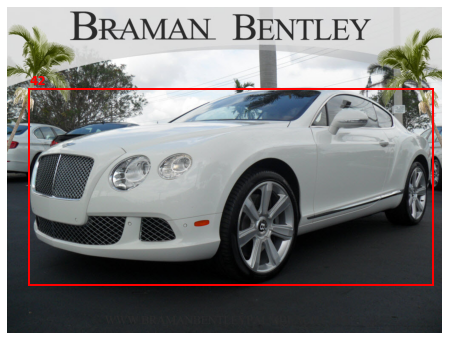

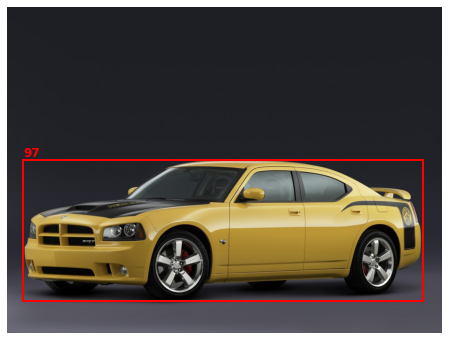

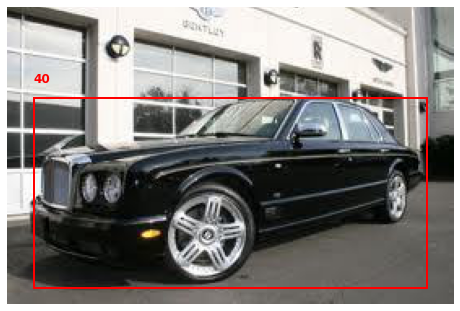

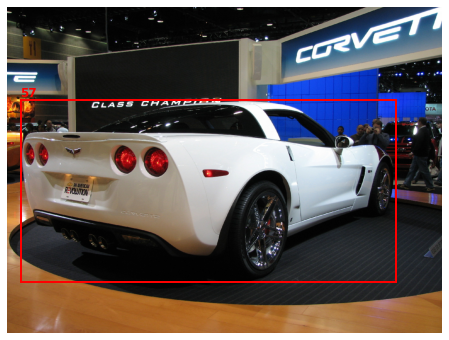

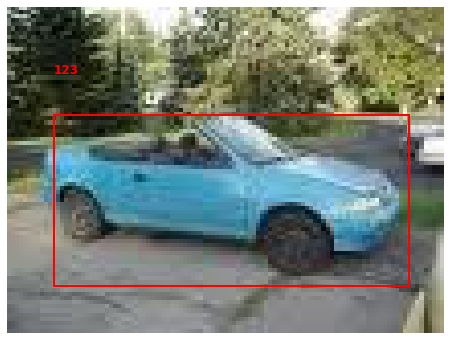

In [31]:
visualize_random_samples(df, IMG_DIR, num_samples=5)

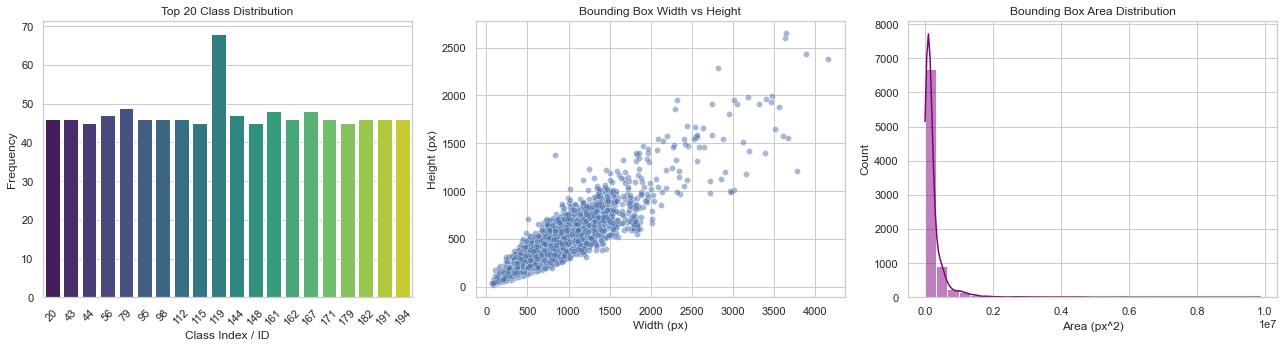

In [32]:
# ==========================================
# 4. Plot Relevant Metrics
# ==========================================
def plot_metrics(df):
    if df is None or df.empty:
        return

    sns.set_theme(style="whitegrid")
    
    # Extract likely column names
    class_col = next((c for c in df.columns if 'class' in c.lower() or 'label' in c.lower()), None)
    x1_col = next((c for c in df.columns if 'x1' in c.lower() or 'xmin' in c.lower()), None)
    y1_col = next((c for c in df.columns if 'y1' in c.lower() or 'ymin' in c.lower()), None)
    x2_col = next((c for c in df.columns if 'x2' in c.lower() or 'xmax' in c.lower()), None)
    y2_col = next((c for c in df.columns if 'y2' in c.lower() or 'ymax' in c.lower()), None)

    fig_cols = 1 + int(bool(class_col)) + int(bool(x1_col))
    
    plt.figure(figsize=(6 * fig_cols, 5))
    plot_idx = 1
    
    # 1. Class Distribution
    if class_col:
        plt.subplot(1, fig_cols, plot_idx)
        vc = df[class_col].value_counts().head(20) # Top 20 if there are many
        sns.barplot(x=vc.index, y=vc.values, palette="viridis")
        plt.title(f"Top 20 {class_col.capitalize()} Distribution")
        plt.xlabel("Class Index / ID")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45)
        plot_idx += 1
        
    # 2. Bounding Box Distributions
    if all([x1_col, y1_col, x2_col, y2_col]):
        df_numeric = df.copy()
        for c in [x1_col, y1_col, x2_col, y2_col]:
            df_numeric[c] = pd.to_numeric(df_numeric[c], errors='coerce')
            
        df_numeric['bbox_width'] = df_numeric[x2_col] - df_numeric[x1_col]
        df_numeric['bbox_height'] = df_numeric[y2_col] - df_numeric[y1_col]
        df_numeric['bbox_area'] = df_numeric['bbox_width'] * df_numeric['bbox_height']
        
        plt.subplot(1, fig_cols, plot_idx)
        sns.scatterplot(data=df_numeric, x='bbox_width', y='bbox_height', alpha=0.5)
        plt.title("Bounding Box Width vs Height")
        plt.xlabel("Width (px)")
        plt.ylabel("Height (px)")
        plot_idx += 1
        
        plt.subplot(1, fig_cols, plot_idx)
        sns.histplot(df_numeric['bbox_area'].dropna(), bins=30, kde=True, color='purple')
        plt.title("Bounding Box Area Distribution")
        plt.xlabel("Area (px^2)")
        plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

if mat_data and not df.empty:
    plot_metrics(df)